## Implémentation du solveur de Helmholtz 2D en configuration bipériodique, avec CLs de Dirichlet

In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent      # pyTQG
SRC = ROOT / "pyTQG_solver"

print(ROOT)
print(SRC)
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG
C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG\pyTQG_solver


In [3]:
import numpy as np
import numpy.matlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
import time
import hvplot.xarray
import xarray as xr

import matplotlib.colors as colors

#module "maison"
import Chebyshev

In [4]:
Chebyshev.Cheb_mat(8).shape

(8, 8)

On résout 
$$
\left(\partial_y^2+\partial_x^2-\alpha^2\right)\psi(x, y) = RHS(x, y)
$$
sur $x, y \in [-1, 1]$, avec $\psi(x, y=\pm 1) = \cosh(l)\cos(kx)$. La solution est $\psi(x, y) = \cos(kx)\cosh(ly)$ pour $\alpha^2 = k^2-l^2$ et $RHS = \left(l^2 -k^2 - \alpha^2\right)\cos{kx}\cosh{ly}$
Ici, $\alpha^2 = 3$, $k=2$, $l=1$, ce qui donne $RHS = -6\cos{kx}\cosh{ly}$


Au début, on prends $\psi(x, y) = \cosh(y)$, $\psi(x, \pm 1) =  \cosh(1)$, $\alpha = 2$, $RHS(x, y) = -\cosh(y)$

In [5]:
def Solve_Helmholtz(Nx,
                    Ny,
                    alpha2 = 0.0,
                    rhs=0.0,
                    CL_y_inf = 0.0,
                    CL_y_sup = 0.0,
                    interval_x = (0.0, 2.0*np.pi),
                    interval_y = (-1.0, 1.0) ): 
    #génération de la grille
    x = np.linspace(interval_x[0], interval_x[1], Nx, endpoint = False)
    y = Chebyshev.collocation_points(Ny, a = interval_y[0], b = interval_y[1])

    kx = 2.*np.pi*scipy.fft.fftfreq(Nx, d = (interval_x[-1] - interval_x[0])/Nx)
    rhs
    if np.isscalar(rhs) : 
        #print(f"RHS scalar")
        RHS = rhs *np.ones((Nx, Ny))
    elif isinstance(rhs, np.ndarray) and (rhs.shape[0] == Nx or rhs.shape[1] == Ny) : 
        RHS = rhs.copy()
    else:
        raise ValueError(f"rhs must be of size Nx x Ny (rhs.shape = {rhs.shape})")
    
    psi_num = np.zeros((Nx, Ny))
    psi_num_hat = np.zeros((Nx, Ny), dtype = 'complex')
    rhs_hat = scipy.fft.fft(RHS, axis = 0)
    
    
    D = Chebyshev.Cheb_mat(Ny, a = interval_y[0], b = interval_y[1])
    D2 = D@D
    
    if np.isscalar(CL_y_inf) : 
        BC_y_inf = np.ones(Nx) * CL_y_inf
        #print("CL_inf scalar")
    elif ( isinstance(CL_y_inf, np.ndarray) == True ) and ( CL_y_inf.shape[0] == Nx and len(CL_y_inf.shape) == 1 ): 
        #print("CL_inf array")
        BC_y_inf = CL_y_inf.copy()
    else : 
        raise ValueError(f"CL_y_inf must be scalar or 1D array of size Nx (CL_y_inf = {CL_y_inf}")

    if np.isscalar(CL_y_sup) : 
        #print("CL_sup_scalar")
        BC_y_sup = np.ones(Nx) * CL_y_sup
    elif ( isinstance(CL_y_sup, np.ndarray) == True ) and ( CL_y_sup.shape[0] == Nx and len(CL_y_sup.shape) == 1 ): 
        #print("CL_sup array")
        BC_y_sup = CL_y_sup.copy()
    else : 
        raise ValueError(f"CL_y_sup must be scalar or 1D array of size Nx (CL_y_sup = {CL_y_sup}")

    BC_y_inf_hat = scipy.fft.fft(BC_y_inf)
    BC_y_sup_hat = scipy.fft.fft(BC_y_sup)

    alpha2_id = alpha2 * np.eye(Ny)
    
    for i in range(0, Nx):
        kx_i = kx[i]
        rhs_hat_i = rhs_hat[i, :].copy()
        F = -( alpha2 + kx_i**2 )*np.eye(Ny)
        F[0, 0] = 1.0
        F[-1, -1] = 1.0
        F[1:-1, :] += D2[1:-1, :]

        #inv_F = np.linalg.inv(F)
        
        
        BC_hat_inf_i = BC_y_inf_hat[i].copy()
        BC_hat_sup_i = BC_y_sup_hat[i].copy()

        rhs_hat_i[0] = BC_hat_sup_i
        rhs_hat_i[-1] = BC_hat_inf_i

        psi_hat_i = np.linalg.solve(F, rhs_hat_i)
        psi_num_hat[i, :] = psi_hat_i
    
    psi_num = scipy.fft.ifft(psi_num_hat, axis = 0).real
    
    return psi_num
    

Nx = 128
Ny = 128
X.shape (128, 128)
Y.shape (128, 128)
alpha^2 2.0
err [[1.10740306e-11 1.10673692e-11 1.10529363e-11 ... 6.66133815e-16
  4.44089210e-16 0.00000000e+00]
 [1.10740306e-11 1.10673692e-11 1.10529363e-11 ... 6.66133815e-16
  4.44089210e-16 0.00000000e+00]
 [1.10740306e-11 1.10673692e-11 1.10529363e-11 ... 6.66133815e-16
  4.44089210e-16 0.00000000e+00]
 ...
 [1.10740306e-11 1.10673692e-11 1.10529363e-11 ... 6.66133815e-16
  4.44089210e-16 0.00000000e+00]
 [1.10740306e-11 1.10673692e-11 1.10529363e-11 ... 6.66133815e-16
  4.44089210e-16 0.00000000e+00]
 [1.10740306e-11 1.10673692e-11 1.10529363e-11 ... 6.66133815e-16
  4.44089210e-16 0.00000000e+00]], min = 0.0, max = 1.1074030581426086e-11, mediane = 2.6256774532384952e-12


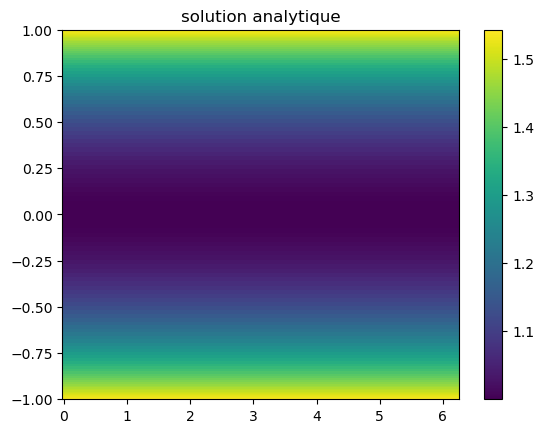

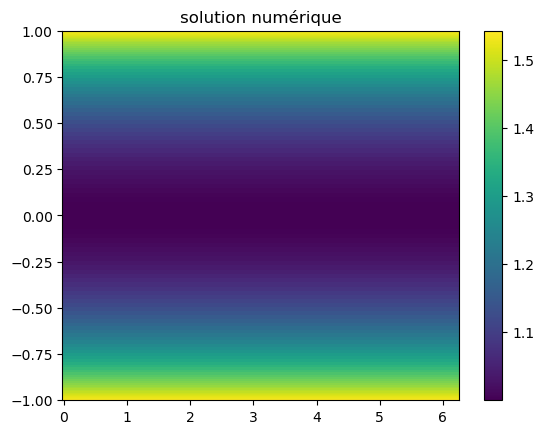

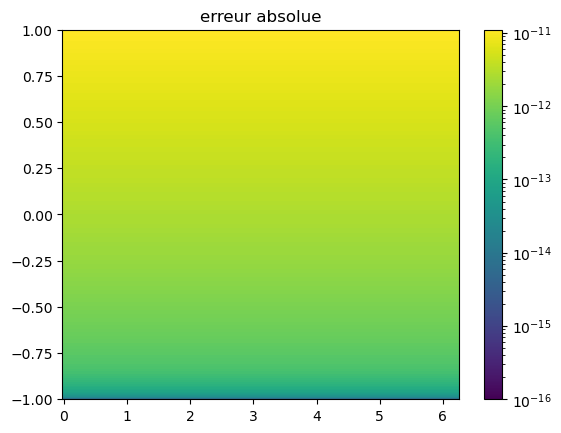

In [6]:
#cas 1D avec psi(x, y) = cosh(y), alpha^2 = 2, rhs = -cosh(y)
Nx= 128
Ny = 128
x_inf = 0.0
x_sup = 2.*np.pi

y_inf = -1.0
y_sup = 1.0

print(f"Nx = {Nx}")
print(f"Ny = {Ny}")

#print(f"y = {y}")
x = np.linspace(x_inf, x_sup, Nx, endpoint = False)
y = Chebyshev.collocation_points(Ny, a=y_inf, b=y_sup)

X, Y = np.meshgrid(x, y, indexing = 'ij')

print(f"X.shape {X.shape}")
print(f"Y.shape {Y.shape}")

k = 2.0
l = 1.
alpha2 = 2.*l**2

print(f'alpha^2 {alpha2}')

rhs = -np.cosh(l*Y)

bc_y1 = np.cosh(l) * np.ones(Nx)
bc_ym1 = bc_y1.copy()


psi_analytique = np.cosh(l*Y)

psi_num = Solve_Helmholtz(Nx,
                          Ny,
                          alpha2 = alpha2,
                          rhs = rhs,
                          CL_y_inf = bc_ym1,
                          CL_y_sup = bc_y1,
                          interval_x = (x_inf, x_sup),
                          interval_y = (y_inf, y_sup))

fig = plt.figure()
ax=plt.axes()
ax.set_title("solution analytique")
cf = ax.pcolormesh(X, Y, psi_analytique)
fig.colorbar(cf, ax=ax)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("solution numérique")
cf = ax.pcolormesh(X, Y, psi_num)
fig.colorbar(cf, ax=ax)

err = np.abs(psi_analytique - psi_num)
print(f"err {err}, min = {err.min()}, max = {err.max()}, mediane = {np.median(err)}")

fig  = plt.figure()
ax=plt.axes()
ax.set_title("erreur absolue")
cf = ax.pcolormesh(X, Y, err, norm=colors.LogNorm(vmin=1.0e-16, vmax=err.max()))
fig.colorbar(cf, ax=ax)



Nx = 512
Ny = 512
X.shape (512, 512)
Y.shape (512, 512)
alpha^2 2.0


'\nerr_rhs = np.abs(err_rhs  -RHS_comp)\n\nfig  = plt.figure()\nax=plt.axes()\nax.set_title("erreur absolue")\ntry:\n    cf = ax.pcolormesh(X, Y, err_rhs, norm=colors.LogNorm(vmin=err_rhs.min(), vmax=err_rhs.max()))\nexcept ValueError:\n    cf = ax.pcolormesh(X, Y, err_rhs, norm=colors.LogNorm(vmin=1.0e-16, vmax=err_rhs.max()))\nfig.colorbar(cf, ax=ax)\n'

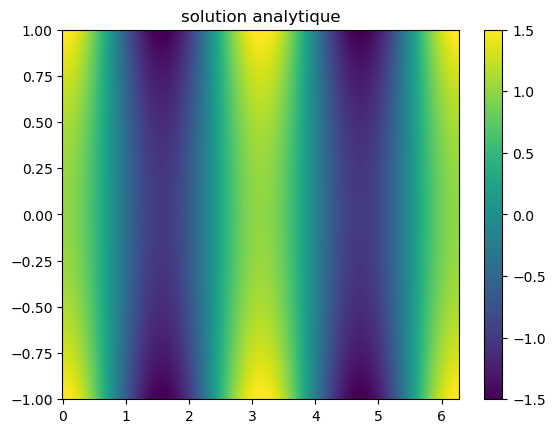

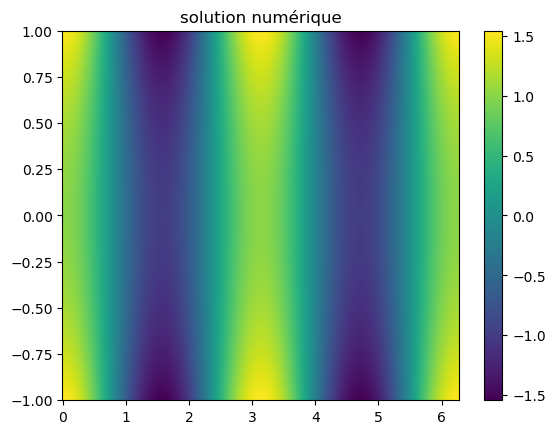

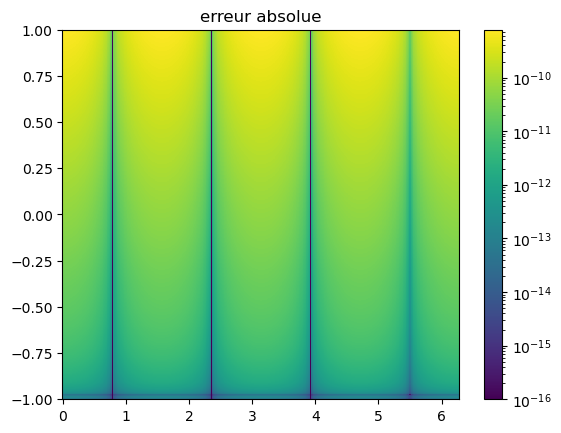

In [7]:
#Cas avec psi(x, y) = 

Nx= 512
Ny = 512
x_inf = 0.0
x_sup = 2.*np.pi

y_inf = -1.0
y_sup = 1.0

print(f"Nx = {Nx}")
print(f"Ny = {Ny}")

#print(f"y = {y}")
x = np.linspace(x_inf, x_sup, Nx, endpoint = False)
y = Chebyshev.collocation_points(Ny, a=y_inf, b=y_sup)

X, Y = np.meshgrid(x, y, indexing = 'ij')

print(f"X.shape {X.shape}")
print(f"Y.shape {Y.shape}")

k = 2.0
l = 1.
alpha2_2 = 3.0

print(f'alpha^2 {alpha2}')

bc_y1_2 = np.cos(k*x)*np.cosh(l)
bc_ym1_2 = np.cos(k*x)*np.cosh(l)

#bc_y1_2 = np.cos(k*x)*np.sinh(l)
#bc_ym1_2 = -np.cos(k*x)*np.sinh(l)



psi_analytique_2 = np.cos(k*X)*np.cosh(l*Y)
#psi_analytique_2 = np.cos(k*X)*np.sinh(l*Y)

rhs_2 = (l**2-k**2-alpha2_2)*np.cos(k*X)*np.cosh(l*Y)
#rhs_2 = -6.0*np.cos(k*X)*np.sinh(l*Y)
#rhs_2 = np.zeros((Nx, Ny))

psi_num_2 = Solve_Helmholtz(Nx,
                            Ny,
                            alpha2 = alpha2_2,
                            rhs = rhs_2,
                            CL_y_inf = bc_ym1_2,
                            CL_y_sup = bc_y1_2,
                            interval_x = (x_inf, x_sup),
                            interval_y = (y_inf, y_sup)
                           )
"""
RHS_comp = (Chebyshev.Cheb_derivative_2D(psi_analytique_2, order = 2, axis =0, a = x_inf, b = x_sup)+
            Chebyshev.Cheb_derivative_2D(psi_analytique_2, order = 2, axis =1, a = y_inf, b = y_sup) - alpha2_2 * psi_analytique_2)
"""
VMAX = max(psi_analytique_2.max(), psi_num_2.max())
VMIN = min(psi_analytique_2.min(), psi_num_2.min())

fig = plt.figure()
ax=plt.axes()
ax.set_title("solution analytique")
cf = ax.pcolormesh(X, Y, psi_analytique_2, vmin = -1.5, vmax = 1.5)
fig.colorbar(cf, ax=ax)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("solution numérique")
cf = ax.pcolormesh(X, Y, psi_num_2, vmin = VMIN, vmax = VMAX)
fig.colorbar(cf, ax=ax)

err_2 = np.abs(psi_analytique_2 - psi_num_2)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("erreur absolue")
cf = ax.pcolormesh(X, Y, err_2, norm=colors.LogNorm(vmin=1.0e-16, vmax=err_2.max()))
fig.colorbar(cf, ax=ax)
"""
err_rhs = np.abs(err_rhs  -RHS_comp)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("erreur absolue")
try:
    cf = ax.pcolormesh(X, Y, err_rhs, norm=colors.LogNorm(vmin=err_rhs.min(), vmax=err_rhs.max()))
except ValueError:
    cf = ax.pcolormesh(X, Y, err_rhs, norm=colors.LogNorm(vmin=1.0e-16, vmax=err_rhs.max()))
fig.colorbar(cf, ax=ax)
"""

Text(0, 0.5, '$\\psi(x, y_0)$')

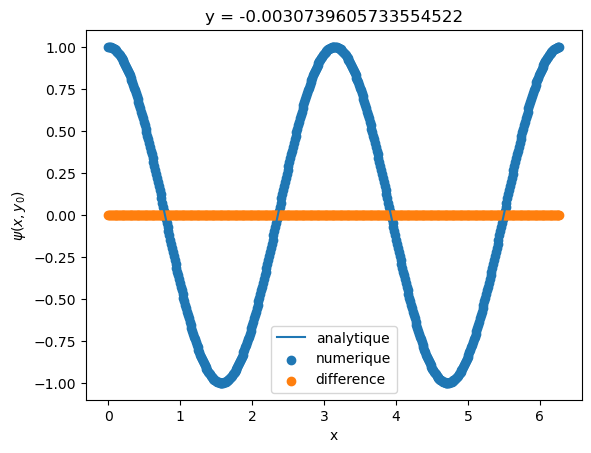

In [8]:
#cas en y = 0
y_0 = 0.0
y_index = np.abs(y - y_0).argmin()

y_sel = y[y_index]
psi_ana_y = psi_analytique_2[:, y_index]
psi_num_y = psi_num_2[:, y_index]

fig = plt.figure()
plt.title(f"y = {y_sel}")
plt.plot(x, psi_ana_y, label = 'analytique')
plt.scatter(x, psi_num_y, label = 'numerique')
plt.scatter(x, psi_ana_y - psi_num_y, label ='difference')
plt.legend()
plt.xlabel('x')
plt.ylabel(r"$\psi(x, y_0)$")


Text(0, 0.5, '$\\epsilon$')

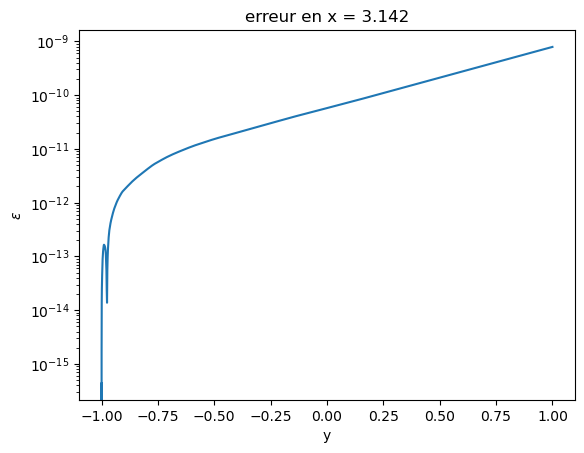

In [9]:
#cas en x = pi
x_sel = np.pi
id_x = np.abs(x-x_sel).argmin()

err_x = np.abs(psi_num_2[id_x, :] - psi_analytique_2[id_x, :])
fig = plt.figure()
plt.title(f"erreur en x = {x[id_x]:.3f}")
plt.semilogy(y, err_x)
plt.xlabel("y")
plt.ylabel(r'$\epsilon$')

[   0.    1.    2.    3.    4.    5.    6.    7.    8.    9.   10.   11.
   12.   13.   14.   15.   16.   17.   18.   19.   20.   21.   22.   23.
   24.   25.   26.   27.   28.   29.   30.   31.   32.   33.   34.   35.
   36.   37.   38.   39.   40.   41.   42.   43.   44.   45.   46.   47.
   48.   49.   50.   51.   52.   53.   54.   55.   56.   57.   58.   59.
   60.   61.   62.   63.   64.   65.   66.   67.   68.   69.   70.   71.
   72.   73.   74.   75.   76.   77.   78.   79.   80.   81.   82.   83.
   84.   85.   86.   87.   88.   89.   90.   91.   92.   93.   94.   95.
   96.   97.   98.   99.  100.  101.  102.  103.  104.  105.  106.  107.
  108.  109.  110.  111.  112.  113.  114.  115.  116.  117.  118.  119.
  120.  121.  122.  123.  124.  125.  126.  127.  128.  129.  130.  131.
  132.  133.  134.  135.  136.  137.  138.  139.  140.  141.  142.  143.
  144.  145.  146.  147.  148.  149.  150.  151.  152.  153.  154.  155.
  156.  157.  158.  159.  160.  161.  162.  163.  1

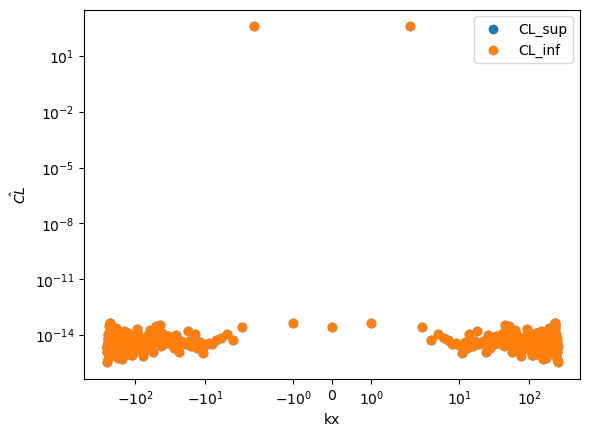

In [10]:
kx = 2.*np.pi*scipy.fft.fftfreq(Nx, d = (x_sup - x_inf)/Nx)

print(kx)

CL_sup_hat = np.abs(scipy.fft.fft(bc_y1_2))
CL_inf_hat = np.abs(scipy.fft.fft(bc_ym1_2))
def sort_k(z_hat,K):
    new_z_hat = z_hat.copy()

    K_argsort = np.argsort(K)
    for i in range(0, z_hat.shape[0]):
        new_z_hat[i] = z_hat[K_argsort[i]]
    return new_z_hat

kx_sorted = np.sort(kx)
fig = plt.figure()
plt.scatter(kx_sorted, sort_k(CL_sup_hat, kx), label = r"CL_sup")
plt.scatter(kx_sorted, sort_k(CL_inf_hat, kx), label = r"CL_inf")

plt.xlabel("kx")
plt.ylabel(r"$\hat{CL}$")
plt.legend()
plt.xscale('symlog')
plt.yscale('log')


for i in range(0, kx.size) : 
    if CL_sup_hat[i] > 1.0e-10 : 
        print(f"mode en kx = {kx[i]}")

Text(0, 0.5, '$|\\hat{\\psi_{ana}} - \\hat{\\psi_{num}}|$')

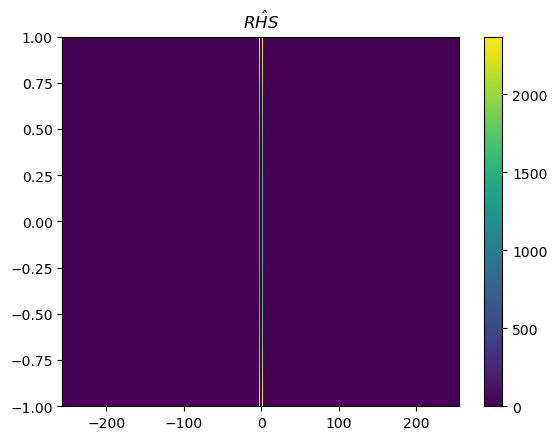

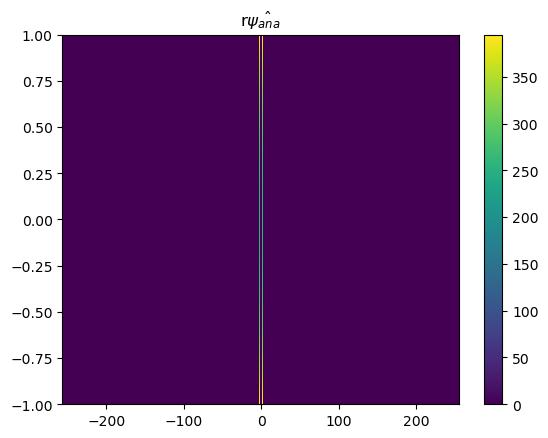

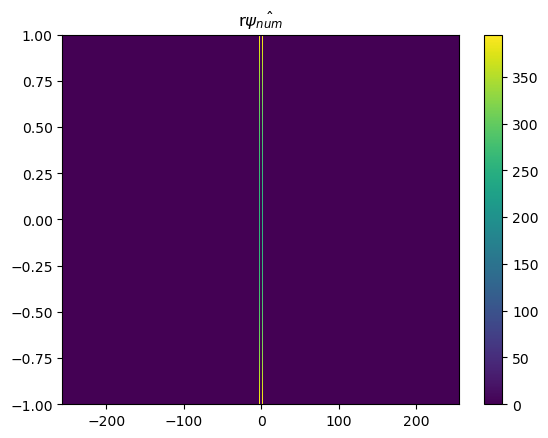

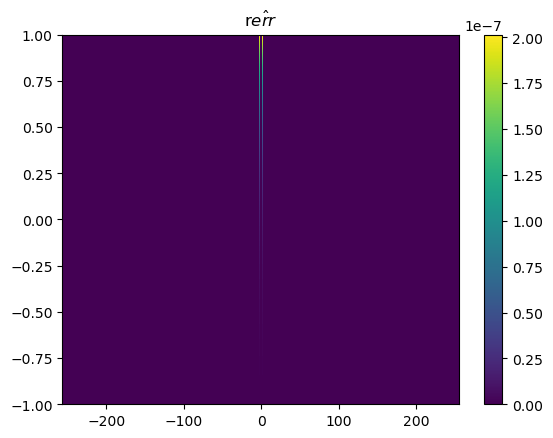

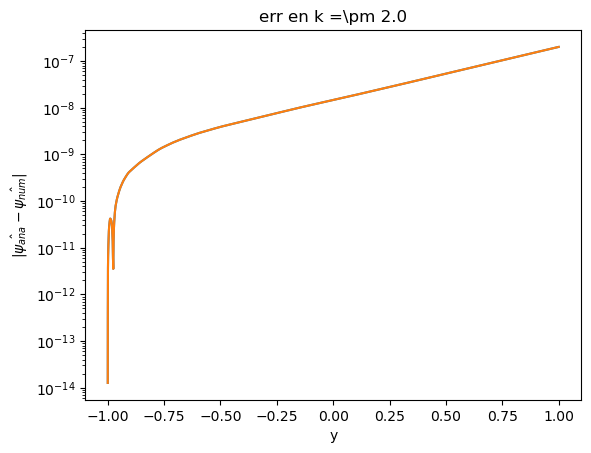

In [11]:
rhs_hat_2 = scipy.fft.fft(rhs_2, axis = 0)
Kx, Y = np.meshgrid(np.sort(kx), y, indexing = 'ij')



fig = plt.figure()
ax=plt.axes()
ax.set_title(r"$\hat{RHS}$")
cf = ax.pcolormesh(Kx, Y, np.abs(sort_k(rhs_hat_2, kx)))
fig.colorbar(cf, ax=ax)

psi_ana_hat = scipy.fft.fft(psi_analytique_2, axis =0)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("r$\hat{\psi_{ana}}$")
cf = ax.pcolormesh(Kx, Y, np.abs(sort_k(psi_ana_hat, kx)))
fig.colorbar(cf, ax=ax)

psi_num_hat_2 = scipy.fft.fft(psi_num_2, axis =0)

fig  = plt.figure()
ax=plt.axes()
ax.set_title("r$\hat{\psi_{num}}$")
cf = ax.pcolormesh(Kx, Y, np.abs(sort_k(psi_num_hat_2, kx)))
fig.colorbar(cf, ax=ax)

err_hat = scipy.fft.fft(psi_num_2 - psi_analytique_2, axis = 0)
fig  = plt.figure()
ax=plt.axes()
ax.set_title("r$\hat{err}$")
cf = ax.pcolormesh(Kx, Y, np.abs(sort_k(err_hat, kx)))
fig.colorbar(cf, ax=ax)

fig = plt.figure()
plt.title(fr"err en k =\pm {k}")
plt.plot(y, np.abs(err_hat[kx==k][0]), label = f"k={k}")
plt.plot(y, np.abs(err_hat[kx==-k][0]), label = f"k = -{k}")
plt.yscale('log')
plt.xlabel("y")
plt.ylabel(r"$|\hat{\psi_{ana}} - \hat{\psi_{num}}|$")

In [12]:
k_sel = k

rhs_modes = rhs_hat_2[kx==k_sel][0]

D2_psi_y = (l**2)*psi_analytique_2
k2_psi = -k**2*psi_analytique_2
alpha2_psi = -alpha2_2  * psi_analytique_2

D2_psi_hat = scipy.fft.fft(D2_psi_y, axis = 0)[kx==k_sel][0, :]

alpha2_psi_hat = scipy.fft.fft(alpha2_psi, axis = 0)[kx==k_sel][0, :]

k2_psi_hat = scipy.fft.fft(k2_psi, axis = 0)[kx==k_sel][0, :]

psi_ana_mode = psi_analytique_2[kx==k][0, :]

psi_ana_hat = scipy.fft.fft(psi_analytique_2, axis = 0)[kx==k_sel][0, :]
psi_ana_mode = scipy.fft.ifft(psi_ana_hat)
sol_num_hat = scipy.fft.fft(psi_num_2, axis =0)[kx==k_sel][0, :]

bc_y1_2_hat = scipy.fft.fft(bc_y1_2)[kx==k_sel]
bc_ym1_2_hat = scipy.fft.fft(bc_ym1_2)[kx==k_sel]

D = Chebyshev.Cheb_mat(Ny)
D2 = D@D




F = -( alpha2_2 + k**2 )*np.eye(Ny)
F[0, 0] = 1.0
F[-1, -1] = 1.0
F[1:-1, :] += D2[1:-1, :]

rhs_test = rhs_modes.copy()

rhs_test[0] = bc_y1_2_hat.copy()
rhs_test[-1] = bc_ym1_2_hat.copy()
inv_F = np.linalg.inv(F)
psi_num_mod_hat = inv_F @ rhs_test
psi_num_mod = scipy.fft.ifft(psi_num_mod_hat).real

print(f"mode kx = k = {k}")


err_num = np.abs(psi_num_mod_hat - psi_ana_hat)

print(f"Erreur numérique : F^-1 @ rhs_test - psi_ana_hat {err_num}, moyenne {np.mean(err_num)}, minimum {err_num.min()}, maximum {err_num.max()}")

err_ifft = np.abs(psi_num_mod - psi_ana_mode)
print(f"Erreur IFFT( psi_num_mod_hat) - psi_ana_mode {err_ifft}, moyenne {np.mean(err_ifft)}, minimum {err_ifft.min()}, maximum {err_ifft.max()}")

psi_ana_from_hat = scipy.fft.ifft(psi_ana_hat)
err_recons = np.abs(psi_num_mod - psi_ana_from_hat)

print(f"Erreur reconstruction : IFFT(psi_num_hat) - IFFT(psi_ana_hat) {err_recons}, moyenne {np.mean(err_recons)}, minimum {err_recons.min()}, maximum {err_recons.max()}")


err_tot = np.abs( F@psi_ana_hat - rhs_modes)

err_CL_inf = np.abs(bc_ym1_2_hat -psi_num_mod_hat[-1])
print(f"Erreur CL inf : psi_num_hat[-1] - bc_ym1_2 {err_CL_inf}")

err_CL_sup = np.abs(bc_y1_2_hat -psi_num_mod_hat[0])
print(f"Erreur CL sup : psi_num_hat[0] - bc_y1_2 {err_CL_inf}")

print(f"Erreur D2 - (alpha2_2+k**2)*np.eye(Ny))@psi_ana_hat-RHS_hat {err_tot}, moyenne {np.mean(err_tot)}, minimum {err_tot.min()}, maximum {err_tot.max()}")

err_D2 = np.abs(D2@psi_ana_hat-D2_psi_hat)

print(f"Erreur D2@psi_ana_hat - D2_psi_hat_y {err_D2}, moyenne {np.mean(err_D2)}, minimum {err_D2.min()}, maximum {err_D2.max()}")


err_k2 = np.abs( (-k**2 *np.eye(Ny))@ psi_ana_hat - k2_psi_hat )
print(f"Erreur -k**2 * psi_ana_hat - k2_psi_hat {err_k2}, moyenne {np.mean(err_k2)}, minimum {err_k2.min()}, maximum {err_k2.max()}")

err_alpha = np.abs(( -alpha2_2 * np.eye(Ny) ) @ psi_ana_hat - alpha2_psi_hat)
print(f"Erreur -alpha2_2 *psi_ana_hat - alpha2_psi_hat {err_k2}, moyenne {np.mean(err_alpha)}, minimum {err_alpha.min()}, maximum {err_alpha.max()}")

mode kx = k = 2.0
Erreur numérique : F^-1 @ rhs_test - psi_ana_hat [1.22249844e-07 1.22244160e-07 1.22226652e-07 1.22195388e-07
 1.22151675e-07 1.22097049e-07 1.22030599e-07 1.21952667e-07
 1.21864957e-07 1.21765027e-07 1.21653386e-07 1.21529467e-07
 1.21395090e-07 1.21252185e-07 1.21097685e-07 1.20932043e-07
 1.20755203e-07 1.20565517e-07 1.20362927e-07 1.20147831e-07
 1.19920571e-07 1.19682738e-07 1.19434503e-07 1.19172341e-07
 1.18899607e-07 1.18615048e-07 1.18321111e-07 1.18016203e-07
 1.17700324e-07 1.17374441e-07 1.17039917e-07 1.16694935e-07
 1.16339493e-07 1.15974046e-07 1.15598880e-07 1.15212401e-07
 1.14816089e-07 1.14409602e-07 1.13994304e-07 1.13568717e-07
 1.13133808e-07 1.12688042e-07 1.12233124e-07 1.11766894e-07
 1.11290433e-07 1.10804820e-07 1.10311362e-07 1.09807161e-07
 1.09293069e-07 1.08770109e-07 1.08238680e-07 1.07700089e-07
 1.07153824e-07 1.06599657e-07 1.06038215e-07 1.05469098e-07
 1.04892877e-07 1.04306935e-07 1.03715706e-07 1.03118396e-07
 1.02513866e-07 1.

C:\Users\evanl\AppData\Local\Temp\ipykernel_18872\2754665203.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rhs_test[0] = bc_y1_2_hat.copy()
C:\Users\evanl\AppData\Local\Temp\ipykernel_18872\2754665203.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rhs_test[-1] = bc_ym1_2_hat.copy()


err_hat_test : mediane = 2.0376903084443964e-15, max = 1.2224984402564587e-07, min = 0.0
err_num_test : mediane = 1.742309074810246e-11, max = 4.775384532251792e-10, min = 0.0


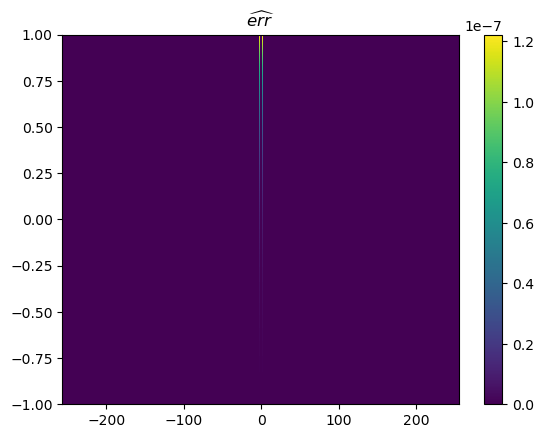

<Figure size 640x480 with 0 Axes>

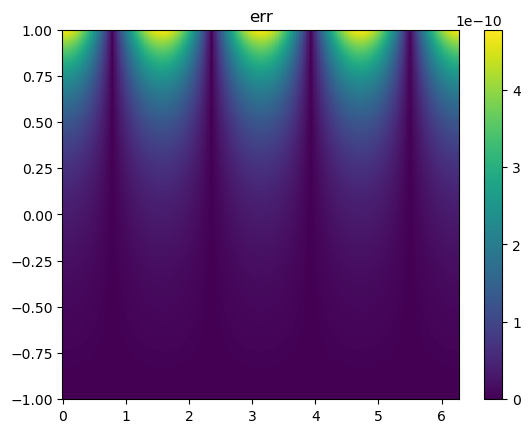

In [13]:
#Réimplémentation
kx = 2.*np.pi*scipy.fft.fftfreq(Nx, d = (x_sup - x_inf)/Nx)


psi_num_hat_test = np.zeros((Nx, Ny), dtype='complex')
psi_num_test = np.zeros((Nx, Ny), dtype='complex')
rhs_hat_test = scipy.fft.fft(rhs_2, axis = 0)

bc_y1_2_hat = scipy.fft.fft(bc_y1_2)
bc_ym1_2_hat = scipy.fft.fft(bc_ym1_2)

D = Chebyshev.Cheb_mat(Ny)
D2 = D@D

for i in range(0, kx.size):
    
    F = -( alpha2_2 + kx[i]**2 )*np.eye(Ny)
    F[0, 0] = 1.0
    F[-1, -1] = 1.0
    F[1:-1, :] += D2[1:-1, :]
    rhs_hat_i = rhs_hat_test[i, :].copy()
    rhs_hat_i[0] = bc_y1_2_hat[i].copy()
    rhs_hat_i[-1] = bc_ym1_2_hat[i].copy()
    inv_F = np.linalg.inv(F)
    psi_num_hat_test[i, :] = inv_F @rhs_hat_i

psi_ana_hat = scipy.fft.fft(psi_analytique_2, axis=0)

err_hat_test = np.abs(psi_ana_hat.real - psi_num_hat_test.real)

psi_num_test = scipy.fft.ifft(psi_num_hat_test, axis =0)
err_num_test = np.abs(psi_num_test - psi_analytique_2)

print(f"err_hat_test : mediane = {np.median(err_hat_test)}, max = {err_hat_test.max()}, min = {err_hat_test.min()}")
print(f"err_num_test : mediane = {np.median(err_num_test)}, max = {err_num_test.max()}, min = {err_num_test.min()}")


Kx, Y = np.meshgrid(np.sort(kx), y, indexing = 'ij')
fig  = plt.figure()
ax=plt.axes()
ax.set_title(r"$\widehat{err}$")
cf = ax.pcolormesh(Kx, Y, np.abs(sort_k(err_hat_test, kx)))
fig.colorbar(cf, ax=ax)

fig= plt.figure()
fig  = plt.figure()
ax=plt.axes()
ax.set_title(r"err")
cf = ax.pcolormesh(X, Y, err_num_test)
fig.colorbar(cf, ax=ax)


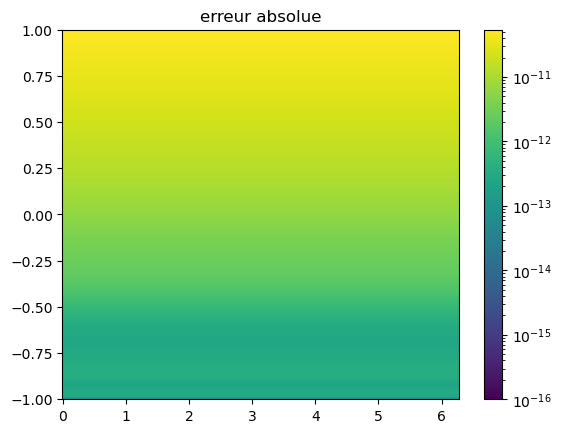

In [15]:
#cas psi(x, y = 1.0)
sol_ana = 1.0*np.ones((Nx, Ny))
psi_num_3 = Solve_Helmholtz(Nx,
                            Ny,
                            alpha2 = 3.0,
                            rhs = -3.0,
                            CL_y_inf = 1.0,
                            CL_y_sup = 1.0,
                            interval_x = (x_inf, x_sup),
                            interval_y = (y_inf, y_sup)
                           )
fig = plt.figure()
err_3 = np.abs(sol_ana-psi_num_3)
ax=plt.axes()
ax.set_title("erreur absolue")
cf = ax.pcolormesh(X, Y, err_3, norm=colors.LogNorm(vmin=1.0e-16, vmax=err_3.max()))
fig.colorbar(cf, ax=ax)

In [ ]:
sort_k(rhs_hat_2, kx).shape

In [ ]:
(l**2-k**2 - alpha2_2)*psi_analytique_2 - rhs_2

FFT(x) = [-2.06199573e-14-0.00000000e+00j  2.56000000e+02-2.96658395e-14j
  6.14793483e-15+9.12886543e-16j  9.16401048e-16-4.98840780e-16j
  2.00446727e-15-1.28486924e-15j -3.69829117e-15+4.66383465e-15j
  1.56095016e-15+2.93696355e-16j  4.28200616e-15-5.98868195e-15j
 -4.69715541e-16+2.87335730e-15j  1.06897224e-15-5.36505087e-15j
  2.66036121e-16-1.02999713e-15j  1.52156313e-15+6.83951214e-16j
  5.87116660e-16+2.27046738e-16j -8.10765275e-16-1.98629366e-18j
 -1.02838909e-15-1.20510039e-15j -2.06225165e-16-3.44248421e-15j
  2.14239726e-16+5.53571950e-17j -2.82648914e-15-4.45976489e-15j
  1.40735018e-15-3.03080801e-16j -7.97009524e-16+7.57148299e-16j
 -2.16793155e-16-1.80631317e-15j  6.08145703e-16+1.77405261e-15j
 -1.02932906e-15+2.36701404e-16j -1.77669567e-15-2.05849910e-15j
  4.03323882e-16+7.88292542e-16j -3.36660317e-15-1.03122094e-15j
  1.32830011e-15+2.14493648e-16j  7.23342314e-16+2.59979610e-15j
 -4.01174553e-16+6.77866912e-16j  1.79389753e-15+9.96878504e-16j
 -1.77880123e-15

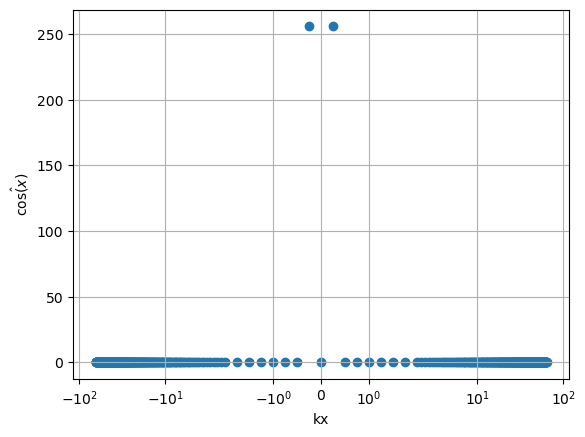

In [16]:
N = 128
xx = np.linspace(0.0, 2.0*np.pi, N, endpoint = False)

cos_x = np.cos(x)
cos_x_hat = scipy.fft.fft(cos_x)
print(f"FFT(x) = {cos_x_hat}")
kxx = 2.*np.pi*scipy.fft.fftfreq(Nx, d = 2.0*np.pi/N)
arg_max_x = np.argmax(cos_x_hat)
print(f"kxx = {kxx}")

print(f"amplitude max {np.abs(cos_x_hat).max()} en kxx = {kxx[arg_max_x]}")


fig = plt.figure()
kx_sorted = np.sort(kxx)
plt.scatter(kx_sorted, sort_k(cos_x_hat.real, kxx), label = r"CL_sup")
plt.xlabel("kx")
plt.ylabel(r"$\hat{\cos(x)}$")

plt.xscale('symlog')
#plt.yscale('log')
plt.grid(True)

for i in range(0, kxx.size):
    if np.abs(cos_x_hat[i]) > 1.0e-12 : 
        print(f"mode d'amplitude {cos_x_hat[i]} en kxx = {kxx[i]}")

In [ ]:
np.pi/4.0

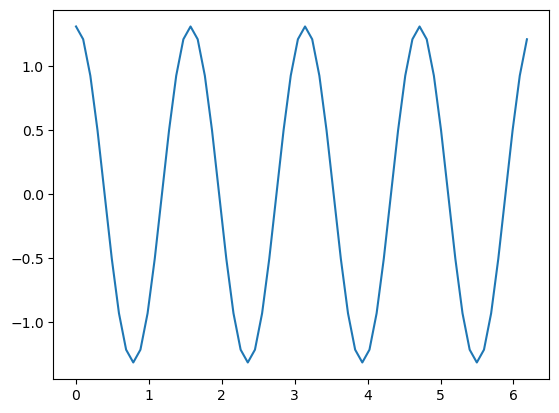

In [17]:
#test avec mode k=2 artificiel
N=64
N_mode = 4
psi_hat_test =np.zeros(N, dtype = 'complex')
psi_hat_test[N_mode] = 42.0+0.0j
psi_hat_test[N-N_mode] = 42.0+0.0j
psi_test = scipy.fft.ifft(psi_hat_test)

kk = scipy.fft.fftfreq(N, d = 2.0*np.pi/N)*2.0*np.pi
xx = np.linspace(0.0, 2.0*np.pi, N, endpoint = False)

fig = plt.figure()
plt.plot(xx, psi_test.real)

[0.00000000e+00 0.00000000e+00 2.22044605e-16 4.44089210e-16
 0.00000000e+00 0.00000000e+00 6.66133815e-16 4.44089210e-16
 2.22044605e-16 0.00000000e+00 2.22044605e-16 2.22044605e-16
 0.00000000e+00 2.22044605e-16 0.00000000e+00 2.22044605e-16
 0.00000000e+00 2.22044605e-16 2.22044605e-16 4.44089210e-16
 4.44089210e-16 6.66133815e-16 2.22044605e-16 0.00000000e+00
 2.22044605e-16 4.44089210e-16 2.22044605e-16 2.22044605e-16
 4.44089210e-16 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 4.44089210e-16
 1.11022302e-16 1.11022302e-16 5.55111512e-16 1.11022302e-16
 2.22044605e-16 1.11022302e-16 1.11022302e-16 2.22044605e-16
 2.22044605e-16 1.11022302e-16 0.00000000e+00 0.00000000e+00
 1.11022302e-16 1.11022302e-16 0.00000000e+00 4.99600361e-16
 1.66533454e-16 4.44089210e-16 1.66533454e-16 1.66533454e-16
 1.11022302e-16 2.77555756e-16 8.32667268e-17 2.49800181e-16
 8.32667268e-17 1.38777878e-16 5.55111512e-17 1.11022302e-16
 2.46519033e-32 6.245004

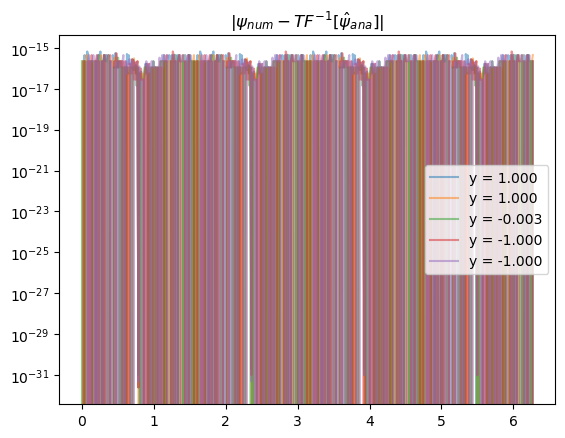

In [18]:
#test de l'ifft sur une ligne

liste_j = [0, 1, Ny//2, Ny-2, Ny-1]

fig = plt.figure()
for j in range(0, len(liste_j)): 
    err_i = np.abs(psi_num_2[:, j] - scipy.fft.ifft(psi_num_hat_2[:, j]).real)
    print(err_i)
    plt.plot(x, err_i, label = f"y = {y[liste_j[j]]:.3f}", alpha =0.5)
plt.yscale('log')
plt.title(r"$|\psi_{num} - TF^{-1}[\hat{\psi}_{ana}]|$")
plt.legend()

In [19]:
%timeit Solve_Helmholtz(Nx, Ny, alpha2 = alpha2_2, rhs = rhs_2, CL_y_inf = bc_ym1_2, CL_y_sup = bc_y1_2, interval_x = (x_inf, x_sup), interval_y = (y_inf, y_sup) )

8.71 s ± 1.47 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [6]:
import numpy as np
import sys

In [7]:
x = np.array([i for i in range(0, 10)])
print(x)
print(x.shape)
print(x.nbytes)
print(sys.getsizeof(x))

[0 1 2 3 4 5 6 7 8 9]
(10,)
40
152


In [10]:
np.sum(x)

45